<a href="https://colab.research.google.com/github/hassnainnisar/Predict_seismic_events_from_geological_features_Machine_Learning_MOD_B/blob/main/Machine_Learning_MOD_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning-Based Prediction of Seismic Activity at Campi Flegrei Using Temporal Features**

**Project Objective**

To develop machine learning regression models capable of predicting future seismic activity at the Campi Flegrei caldera using historical seismic characteristics and temporal features.

**Problem Statement**

Campi Flegrei is an active volcanic area near Naples, Italy, where seismic activity is an important indicator of changes occurring within the volcanic system. The objective of this project is to analyze historical seismic data and develop machine learning models to predict future seismic activity. The project focuses on temporal patterns in seismic events, including event frequency, magnitude, depth, and historical activity. Time-series features such as lagged observations and rolling statistics will be engineered and used as input variables for regression models.

**Dataset:**
Campi Flegrei Caldera Seismic Data

**Source:**
Zenodo

**Data Type:**
Temporal / Time-Series Data

**ML Task:**
Regression

**Target:**
Future Seismic Event Count

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

**Load Dataset**

In [2]:
import pandas as pd

file_path = "https://raw.githubusercontent.com/hassnainnisar/Predict_seismic_events_from_geological_features_Machine_Learning_MOD_B/main/Campi__Seismic_dataset.xlsx"

# Check available sheets
excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# df_1982_1984 = pd.read_excel(
#     file_path,
#     sheet_name='1982-1984'
# )

df_2000_2024 = pd.read_excel(
    file_path,
    sheet_name='2000-2024'
)

In [4]:
print("2000–2024 dataset shape:", df_2000_2024.shape)
# print("Rows:", df_2000_2024.shape[0])
# print("Columns:", df_2000_2024.shape[1])

2000–2024 dataset shape: (8703, 6)


In [5]:
# print("\n1982–1984:")
# display(df_1982_1984.head())

print("\n2000–2024:")
display(df_2000_2024.head())


2000–2024:


,Time\n (MM/DD/YYYY),Seismic Event Count,Unnamed: 2,Time\n(MM/DD/YYYY),Magnitude (Mw),Depth (km)
0,2000-01-15,0.0,NaN,2005-03-15,0.36,1.39
1,2000-02-15,0.0,NaN,2005-03-15,-0.49,1.00
2,2000-03-15,0.0,NaN,2005-05-15,0.80,1.14
3,2000-04-15,0.0,NaN,2005-06-15,0.40,2.00
4,2000-05-15,0.0,NaN,2005-09-15,0.60,2.00


In [6]:

print("\n2000–2024 dataset:")
print("Rows:", df_2000_2024.shape[0])
print("Columns:", df_2000_2024.shape[1])


2000–2024 dataset:
Rows: 8703
Columns: 6


In [7]:
print("\n2000–2024:")
display(df_2000_2024.head(10))

print("\n2000–2024:")
display(df_2000_2024.tail(10))


2000–2024:


,Time\n (MM/DD/YYYY),Seismic Event Count,Unnamed: 2,Time\n(MM/DD/YYYY),Magnitude (Mw),Depth (km)
0,2000-01-15,0.0,NaN,2005-03-15,0.36,1.39
1,2000-02-15,0.0,NaN,2005-03-15,-0.49,1.00
2,2000-03-15,0.0,NaN,2005-05-15,0.80,1.14
3,2000-04-15,0.0,NaN,2005-06-15,0.40,2.00
4,2000-05-15,0.0,NaN,2005-09-15,0.60,2.00
5,2000-06-15,0.0,NaN,2005-10-15,0.70,2.00
6,2000-07-15,0.0,NaN,2005-10-15,0.60,1.26
7,2000-08-15,0.0,NaN,2005-10-15,-0.10,1.61
8,2000-09-15,0.0,NaN,2005-10-15,1.10,2.28
9,2000-10-15,0.0,NaN,2005-10-15,0.60,1.71



2000–2024:


,Time\n (MM/DD/YYYY),Seismic Event Count,Unnamed: 2,Time\n(MM/DD/YYYY),Magnitude (Mw),Depth (km)
8693,NaT,NaN,NaN,2024-11-15,1.0,2.85
8694,NaT,NaN,NaN,2024-11-15,0.5,1.41
8695,NaT,NaN,NaN,2024-11-15,0.9,1.30
8696,NaT,NaN,NaN,2024-11-15,-0.3,1.11
8697,NaT,NaN,NaN,2024-11-15,1.6,2.23
8698,NaT,NaN,NaN,2024-11-15,1.0,1.84
8699,NaT,NaN,NaN,2024-11-15,0.5,1.56
8700,NaT,NaN,NaN,2024-11-15,0.6,1.54
8701,NaT,NaN,NaN,2024-11-15,0.4,1.57
8702,NaT,NaN,NaN,2024-11-15,0.6,3.05


In [8]:
print(df_2000_2024.columns.tolist())

['Time\n (MM/DD/YYYY)', 'Seismic Event Count', 'Unnamed: 2', 'Time\n(MM/DD/YYYY)', 'Magnitude (Mw)', 'Depth (km)']


In [9]:
print("\n2000–2024 columns:")
for i, column in enumerate(df_2000_2024.columns):
    print(i, ":", column)



2000–2024 columns:
0 : Time
 (MM/DD/YYYY)
1 : Seismic Event Count
2 : Unnamed: 2
3 : Time
(MM/DD/YYYY)
4 : Magnitude (Mw)
5 : Depth (km)


In [10]:
print("\n2000–2024 data types:")
print(df_2000_2024.dtypes)


2000–2024 data types:
Time\n (MM/DD/YYYY)    datetime64[ns]
Seismic Event Count           float64
Unnamed: 2                    float64
Time\n(MM/DD/YYYY)     datetime64[ns]
Magnitude (Mw)                float64
Depth (km)                    float64
dtype: object


In [11]:

print("\nMissing values - 2000–2024:")
display(df_2000_2024.isnull().sum())


Missing values - 2000–2024:


,0
Time\n (MM/DD/YYYY),8404
Seismic Event Count,8404
Unnamed: 2,8703
Time\n(MM/DD/YYYY),0
Magnitude (Mw),0
Depth (km),0


In [12]:
df_2000_2024['Unnamed: 2'].isnull().all()

np.True_

In [13]:
first_time = df_2000_2024.iloc[:, 0]
second_time = df_2000_2024.iloc[:, 3]

print("First Time column:")
print(first_time.head())

print("\nSecond Time column:")
print(second_time.head())

First Time column:
0   2000-01-15
1   2000-02-15
2   2000-03-15
3   2000-04-15
4   2000-05-15
Name: Time\n (MM/DD/YYYY), dtype: datetime64[ns]

Second Time column:
0   2005-03-15
1   2005-03-15
2   2005-05-15
3   2005-06-15
4   2005-09-15
Name: Time\n(MM/DD/YYYY), dtype: datetime64[ns]


In [14]:
print("First Time range:")
print(first_time.min(), "to", first_time.max())

print("\nSecond Time range:")
print(second_time.min(), "to", second_time.max())

First Time range:
2000-01-15 00:00:00 to 2024-11-15 00:00:00

Second Time range:
2005-03-15 00:00:00 to 2024-11-15 00:00:00


In [15]:
print("Seismic Event Count statistics:")
print(
    df_2000_2024['Seismic Event Count'].describe()
)

Seismic Event Count statistics:
count    299.000000
mean      29.107023
std       86.110250
min        0.000000
25%        0.000000
50%        1.000000
75%       15.000000
max      739.000000
Name: Seismic Event Count, dtype: float64


In [16]:
print("Magnitude statistics:")
print(
    df_2000_2024['Magnitude (Mw)'].describe()
)

Magnitude statistics:
count    8703.000000
mean        0.413637
std         0.601075
min        -1.100000
25%         0.090000
50%         0.360000
75%         0.700000
max         4.400000
Name: Magnitude (Mw), dtype: float64


In [17]:
print("Depth statistics:")
print(
    df_2000_2024['Depth (km)'].describe()
)

Depth statistics:
count    8703.000000
mean        1.779136
std         0.727187
min         0.000000
25%         1.290000
50%         1.680000
75%         2.230000
max         5.950000
Name: Depth (km), dtype: float64


In [18]:
number_of_events = (
    df_2000_2024['Magnitude (Mw)']
    .notna()
    .sum()
)

print(
    "Number of individual seismic events:",
    number_of_events
)

Number of individual seismic events: 8703


In [19]:
number_of_months = (
    df_2000_2024.iloc[:, 0]
    .dropna()
    .nunique()
)

print(
    "Number of monthly event-count observations:",
    number_of_months
)

Number of monthly event-count observations: 299


In [20]:
event_dates = (
    df_2000_2024.iloc[:, 3]
    .dropna()
)

print(
    "Number of unique event dates:",
    event_dates.nunique()
)

print(
    "Number of individual event records:",
    event_dates.shape[0]
)

Number of unique event dates: 171
Number of individual event records: 8703


In [21]:
print(
    event_dates.value_counts().head(10)
)

Time\n(MM/DD/YYYY)
2024-05-15    739
2024-04-15    730
2023-08-15    503
2023-09-15    456
2024-06-15    348
2024-07-15    300
2024-08-15    290
2023-10-15    289
2023-05-15    264
2024-03-15    242
Name: count, dtype: int64


In [22]:
event_count = (
    df_2000_2024['Seismic Event Count']
    .dropna()
)

print(
    "Number of months with zero events:",
    (event_count == 0).sum()
)

print(
    "Minimum event count:",
    event_count.min()
)

print(
    "Maximum event count:",
    event_count.max()
)

Number of months with zero events: 128
Minimum event count: 0.0
Maximum event count: 739.0


In [23]:
magnitude = (
    df_2000_2024['Magnitude (Mw)']
    .dropna()
)

print(
    "Minimum magnitude:",
    magnitude.min()
)

print(
    "Number of negative magnitudes:",
    (magnitude < 0).sum()
)

Minimum magnitude: -1.1
Number of negative magnitudes: 1875


In [24]:
depth = (
    df_2000_2024['Depth (km)']
    .dropna()
)

print(
    "Minimum depth:",
    depth.min()
)

print(
    "Maximum depth:",
    depth.max()
)

print(
    "Number of negative depths:",
    (depth < 0).sum()
)

Minimum depth: 0.0
Maximum depth: 5.95
Number of negative depths: 0


In [25]:
event_data_preview = df_2000_2024.iloc[:, [3, 4, 5]].dropna()

print("First individual events:")
display(event_data_preview.head(10))

print("Last individual events:")
display(event_data_preview.tail(10))

First individual events:


,Time\n(MM/DD/YYYY),Magnitude (Mw),Depth (km)
0,2005-03-15,0.36,1.39
1,2005-03-15,-0.49,1.00
2,2005-05-15,0.80,1.14
3,2005-06-15,0.40,2.00
4,2005-09-15,0.60,2.00
5,2005-10-15,0.70,2.00
6,2005-10-15,0.60,1.26
7,2005-10-15,-0.10,1.61
8,2005-10-15,1.10,2.28
9,2005-10-15,0.60,1.71


Last individual events:


,Time\n(MM/DD/YYYY),Magnitude (Mw),Depth (km)
8693,2024-11-15,1.0,2.85
8694,2024-11-15,0.5,1.41
8695,2024-11-15,0.9,1.30
8696,2024-11-15,-0.3,1.11
8697,2024-11-15,1.6,2.23
8698,2024-11-15,1.0,1.84
8699,2024-11-15,0.5,1.56
8700,2024-11-15,0.6,1.54
8701,2024-11-15,0.4,1.57
8702,2024-11-15,0.6,3.05


In [26]:
monthly_data_preview = (
    df_2000_2024.iloc[:, [0, 1]]
    .dropna(subset=[df_2000_2024.columns[0]])
)

print(
    "Total monthly rows:",
    len(monthly_data_preview)
)

print(
    "Unique monthly dates:",
    monthly_data_preview.iloc[:, 0].nunique()
)

print(
    "Duplicate monthly dates:",
    monthly_data_preview.iloc[:, 0].duplicated().sum()
)

Total monthly rows: 299
Unique monthly dates: 299
Duplicate monthly dates: 0


In [27]:
# Create monthly event-count data
monthly_count_data = df_2000_2024.iloc[:, [0, 1]].copy()

monthly_count_data.columns = [
    'Month',
    'Seismic_Event_Count'
]

monthly_count_data = (
    monthly_count_data
    .dropna(subset=['Month'])
)

# Create individual-event data
event_data = df_2000_2024.iloc[:, [3, 4, 5]].copy()

event_data.columns = [
    'Event_Date',
    'Magnitude',
    'Depth'
]

event_data = (
    event_data
    .dropna(subset=['Event_Date'])
)

# Count individual events for each month
event_monthly_count = (
    event_data
    .groupby('Event_Date')
    .size()
    .reset_index(name='Individual_Event_Count')
)

# Compare both datasets
count_comparison = monthly_count_data.merge(
    event_monthly_count,
    left_on='Month',
    right_on='Event_Date',
    how='inner'
)

count_comparison['Difference'] = (
    count_comparison['Seismic_Event_Count']
    -
    count_comparison['Individual_Event_Count']
)

display(count_comparison.head(20))

,Month,Seismic_Event_Count,Event_Date,Individual_Event_Count,Difference
0,2005-03-15,2.0,2005-03-15,2,0.0
1,2005-05-15,1.0,2005-05-15,1,0.0
2,2005-06-15,1.0,2005-06-15,1,0.0
3,2005-09-15,1.0,2005-09-15,1,0.0
4,2005-10-15,5.0,2005-10-15,5,0.0
5,2005-11-15,1.0,2005-11-15,1,0.0
6,2006-01-15,1.0,2006-01-15,1,0.0
7,2006-02-15,1.0,2006-02-15,1,0.0
8,2006-03-15,1.0,2006-03-15,1,0.0
9,2006-04-15,1.0,2006-04-15,1,0.0


In [28]:
print(
    "Number of overlapping months:",
    len(count_comparison)
)

print(
    "Months where counts match:",
    (
        count_comparison['Difference'] == 0
    ).sum()
)

print(
    "Months where counts DO NOT match:",
    (
        count_comparison['Difference'] != 0
    ).sum()
)

Number of overlapping months: 171
Months where counts match: 171
Months where counts DO NOT match: 0


In [29]:
# display(
#     count_comparison[
#         count_comparison['Difference'] != 0
#     ].head(20)
# )

# **PART:3**

In [30]:
monthly_data =df_2000_2024.iloc[:, [0, 1]].copy()

monthly_data.columns = [
    'Month',
    'Seismic_Event_Count'
]

monthly_data = monthly_data.dropna(
    subset=['Month']
)

monthly_data['Month'] = pd.to_datetime(
    monthly_data['Month']
)

monthly_data = monthly_data.sort_values(
    'Month'
).reset_index(drop=True)

print("Monthly dataset shape:", monthly_data.shape)

display(monthly_data.head())

Monthly dataset shape: (299, 2)


,Month,Seismic_Event_Count
0,2000-01-15,0.0
1,2000-02-15,0.0
2,2000-03-15,0.0
3,2000-04-15,0.0
4,2000-05-15,0.0


In [31]:
event_data = df_2000_2024.iloc[:, [3, 4, 5]].copy()

event_data.columns = [
    'Event_Date',
    'Magnitude',
    'Depth'
]

event_data = event_data.dropna(
    subset=['Event_Date']
)

event_data['Event_Date'] = pd.to_datetime(
    event_data['Event_Date']
)

event_data = event_data.sort_values(
    'Event_Date'
).reset_index(drop=True)

print("Event dataset shape:", event_data.shape)

display(event_data.head())

Event dataset shape: (8703, 3)


,Event_Date,Magnitude,Depth
0,2005-03-15,0.36,1.39
1,2005-03-15,-0.49,1.00
2,2005-05-15,0.80,1.14
3,2005-06-15,0.40,2.00
4,2005-09-15,0.60,2.00


In [32]:
event_data['Month'] = (
    event_data['Event_Date']
    .dt.to_period('M')
    .dt.to_timestamp()
)


display(
    event_data[
        ['Event_Date', 'Month', 'Magnitude', 'Depth']
    ].head(10)
)

,Event_Date,Month,Magnitude,Depth
0,2005-03-15,2005-03-01,0.36,1.39
1,2005-03-15,2005-03-01,-0.49,1.00
2,2005-05-15,2005-05-01,0.80,1.14
3,2005-06-15,2005-06-01,0.40,2.00
4,2005-09-15,2005-09-01,0.60,2.00
5,2005-10-15,2005-10-01,0.70,2.00
6,2005-10-15,2005-10-01,0.60,1.26
7,2005-10-15,2005-10-01,-0.10,1.61
8,2005-10-15,2005-10-01,1.10,2.28
9,2005-10-15,2005-10-01,0.60,1.71


In [33]:
monthly_data['Month'] = (
    monthly_data['Month']
    .dt.to_period('M')
    .dt.to_timestamp()
)



In [34]:
monthly_event_features = (
    event_data
    .groupby('Month')
    .agg(
        Avg_Magnitude=('Magnitude', 'mean'),
        Max_Magnitude=('Magnitude', 'max'),
        Avg_Depth=('Depth', 'mean'),
        Max_Depth=('Depth', 'max')
    )
    .reset_index()
)

display(monthly_event_features.head(10))

,Month,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth
0,2005-03-01,-0.065,0.36,1.195,1.39
1,2005-05-01,0.800,0.80,1.140,1.14
2,2005-06-01,0.400,0.40,2.000,2.00
3,2005-09-01,0.600,0.60,2.000,2.00
4,2005-10-01,0.580,1.10,1.772,2.28
5,2005-11-01,1.200,1.20,3.240,3.24
6,2006-01-01,0.600,0.60,2.000,2.00
7,2006-02-01,0.400,0.40,2.000,2.00
8,2006-03-01,0.700,0.70,1.170,1.17
9,2006-04-01,0.900,0.90,1.570,1.57


In [35]:
print(
    "Monthly event-feature observations:",
    len(monthly_event_features)
)

Monthly event-feature observations: 171


In [36]:
combined_data = monthly_data.merge(
    monthly_event_features,
    on='Month',
    how='left'
)


print(
    "Combined dataset shape:",
    combined_data.shape
)

display(
    combined_data.head(10)
)


Combined dataset shape: (299, 6)


,Month,Seismic_Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth
0,2000-01-01,0.0,NaN,NaN,NaN,NaN
1,2000-02-01,0.0,NaN,NaN,NaN,NaN
2,2000-03-01,0.0,NaN,NaN,NaN,NaN
3,2000-04-01,0.0,NaN,NaN,NaN,NaN
4,2000-05-01,0.0,NaN,NaN,NaN,NaN
5,2000-06-01,0.0,NaN,NaN,NaN,NaN
6,2000-07-01,0.0,NaN,NaN,NaN,NaN
7,2000-08-01,0.0,NaN,NaN,NaN,NaN
8,2000-09-01,0.0,NaN,NaN,NaN,NaN
9,2000-10-01,0.0,NaN,NaN,NaN,NaN


In [37]:
print(
    combined_data.isnull().sum()
)

Month                    0
Seismic_Event_Count      0
Avg_Magnitude          128
Max_Magnitude          128
Avg_Depth              128
Max_Depth              128
dtype: int64


In [38]:
model_data = combined_data[
    combined_data['Month'] >= '2005-03-01'
].copy()

model_data = model_data.sort_values(
    'Month'
).reset_index(drop=True)

print(
    "Modeling dataset shape:",
    model_data.shape
)

display(
    model_data.head()
)

Modeling dataset shape: (237, 6)


,Month,Seismic_Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth
0,2005-03-01,2.0,-0.065,0.36,1.195,1.39
1,2005-04-01,0.0,NaN,NaN,NaN,NaN
2,2005-05-01,1.0,0.800,0.80,1.140,1.14
3,2005-06-01,1.0,0.400,0.40,2.000,2.00
4,2005-07-01,0.0,NaN,NaN,NaN,NaN


In [39]:
print(
    "Missing values in modeling dataset:"
)

print(
    model_data.isnull().sum()
)

Missing values in modeling dataset:
Month                   0
Seismic_Event_Count     0
Avg_Magnitude          66
Max_Magnitude          66
Avg_Depth              66
Max_Depth              66
dtype: int64


In [40]:
print(
    "First modeling month:",
    model_data['Month'].min()
)

print(
    "Last modeling month:",
    model_data['Month'].max()
)

First modeling month: 2005-03-01 00:00:00
Last modeling month: 2024-11-01 00:00:00


In [41]:
verification = model_data[
    ['Month', 'Seismic_Event_Count']
].copy()

verification['Individual_Event_Count'] = (
    event_data
    .groupby('Month')
    .size()
    .reindex(
        verification['Month']
    )
    .values
)

verification['Difference'] = (
    verification['Seismic_Event_Count']
    -
    verification['Individual_Event_Count']
)

display(
    verification.head(10)
)

,Month,Seismic_Event_Count,Individual_Event_Count,Difference
0,2005-03-01,2.0,2.0,0.0
1,2005-04-01,0.0,NaN,NaN
2,2005-05-01,1.0,1.0,0.0
3,2005-06-01,1.0,1.0,0.0
4,2005-07-01,0.0,NaN,NaN
5,2005-08-01,0.0,NaN,NaN
6,2005-09-01,1.0,1.0,0.0
7,2005-10-01,5.0,5.0,0.0
8,2005-11-01,1.0,1.0,0.0
9,2005-12-01,0.0,NaN,NaN


In [42]:
print(
    "Months with count mismatch:",
    (
        verification['Difference'] != 0
    ).sum()
)

Months with count mismatch: 66


In [43]:
mismatches = verification[
    verification['Difference'] != 0
].copy()

print("Number of mismatched months:", len(mismatches))

display(mismatches.head(20))


print("Difference statistics:")
print(mismatches['Difference'].describe())

Number of mismatched months: 66


,Month,Seismic_Event_Count,Individual_Event_Count,Difference
1,2005-04-01,0.0,NaN,NaN
4,2005-07-01,0.0,NaN,NaN
5,2005-08-01,0.0,NaN,NaN
9,2005-12-01,0.0,NaN,NaN
15,2006-06-01,0.0,NaN,NaN
16,2006-07-01,0.0,NaN,NaN
20,2006-11-01,0.0,NaN,NaN
22,2007-01-01,0.0,NaN,NaN
24,2007-03-01,0.0,NaN,NaN
25,2007-04-01,0.0,NaN,NaN


Difference statistics:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Difference, dtype: float64


In [44]:
print("First 10 mismatched months:")
display(
    mismatches[
        ['Month',
         'Seismic_Event_Count',
         'Individual_Event_Count',
         'Difference']
    ].head(10)
)

First 10 mismatched months:


,Month,Seismic_Event_Count,Individual_Event_Count,Difference
1,2005-04-01,0.0,NaN,NaN
4,2005-07-01,0.0,NaN,NaN
5,2005-08-01,0.0,NaN,NaN
9,2005-12-01,0.0,NaN,NaN
15,2006-06-01,0.0,NaN,NaN
16,2006-07-01,0.0,NaN,NaN
20,2006-11-01,0.0,NaN,NaN
22,2007-01-01,0.0,NaN,NaN
24,2007-03-01,0.0,NaN,NaN
25,2007-04-01,0.0,NaN,NaN


In [45]:
print(
    "Months where Event Count > Individual Event Count:",
    (mismatches['Difference'] > 0).sum()
)

print(
    "Months where Event Count < Individual Event Count:",
    (mismatches['Difference'] < 0).sum()
)

print(
    "Months where difference is exactly zero:",
    (verification['Difference'] == 0).sum()
)

Months where Event Count > Individual Event Count: 0
Months where Event Count < Individual Event Count: 0
Months where difference is exactly zero: 171


In [46]:
verification_fixed = verification.copy()

verification_fixed['Individual_Event_Count'] = (
    verification_fixed['Individual_Event_Count']
    .fillna(0)
)

verification_fixed['Difference'] = (
    verification_fixed['Seismic_Event_Count']
    -
    verification_fixed['Individual_Event_Count']
)

print(
    "Months with actual count mismatch:",
    (verification_fixed['Difference'] != 0).sum()
)

Months with actual count mismatch: 0


In [47]:
model_data.shape
model_data.isnull().sum()
model_data.head()

,Month,Seismic_Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth
0,2005-03-01,2.0,-0.065,0.36,1.195,1.39
1,2005-04-01,0.0,NaN,NaN,NaN,NaN
2,2005-05-01,1.0,0.800,0.80,1.140,1.14
3,2005-06-01,1.0,0.400,0.40,2.000,2.00
4,2005-07-01,0.0,NaN,NaN,NaN,NaN


# **Part 4: Exploratory Data Analysis (EDA)**

In [48]:
print("Dataset shape:", model_data.shape)

display(model_data.head())

print("\nData types:")
print(model_data.dtypes)

Dataset shape: (237, 6)


,Month,Seismic_Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth
0,2005-03-01,2.0,-0.065,0.36,1.195,1.39
1,2005-04-01,0.0,NaN,NaN,NaN,NaN
2,2005-05-01,1.0,0.800,0.80,1.140,1.14
3,2005-06-01,1.0,0.400,0.40,2.000,2.00
4,2005-07-01,0.0,NaN,NaN,NaN,NaN



Data types:
Month                  datetime64[ns]
Seismic_Event_Count           float64
Avg_Magnitude                 float64
Max_Magnitude                 float64
Avg_Depth                     float64
Max_Depth                     float64
dtype: object


In [49]:
model_data.describe()

,Month,Seismic_Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth
count,237,237.000000,171.000000,171.000000,171.000000,171.000000
mean,2014-12-31 09:55:26.582278400,36.721519,0.283295,1.331053,1.622918,2.689649
min,2005-03-01 00:00:00,0.000000,-0.800000,-0.800000,0.460000,0.460000
25%,2010-02-01 00:00:00,0.000000,0.111326,0.500000,1.322059,1.830000
50%,2015-01-01 00:00:00,3.000000,0.291709,1.100000,1.608810,2.380000
75%,2019-12-01 00:00:00,24.000000,0.476322,1.995000,1.852666,3.565000
max,2024-11-01 00:00:00,739.000000,1.383333,4.400000,4.300000,5.950000
std,NaN,95.300453,0.366638,1.103028,0.526198,1.249682


In [50]:
zero_event_months = (
    model_data['Seismic_Event_Count'] == 0
).sum()

total_months = len(model_data)

print("Total months:", total_months)
print("Zero-event months:", zero_event_months)
print(
    "Percentage of zero-event months:",
    round(zero_event_months / total_months * 100, 2),
    "%"
)

Total months: 237
Zero-event months: 66
Percentage of zero-event months: 27.85 %


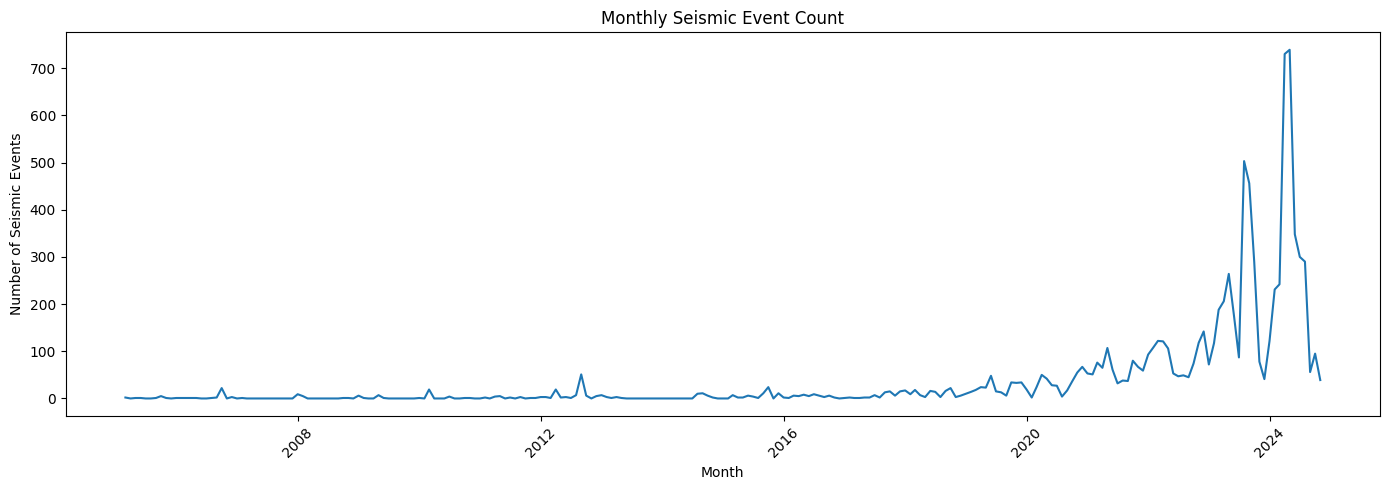

In [51]:
plt.figure(figsize=(14, 5))

plt.plot(
    model_data['Month'],
    model_data['Seismic_Event_Count']
)

plt.title('Monthly Seismic Event Count')
plt.xlabel('Month')
plt.ylabel('Number of Seismic Events')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
top_activity = (
    model_data[
        ['Month', 'Seismic_Event_Count']
    ]
    .sort_values(
        'Seismic_Event_Count',
        ascending=False
    )
    .head(10)
)

display(top_activity)

,Month,Seismic_Event_Count
230,2024-05-01,739.0
229,2024-04-01,730.0
221,2023-08-01,503.0
222,2023-09-01,456.0
231,2024-06-01,348.0
232,2024-07-01,300.0
233,2024-08-01,290.0
223,2023-10-01,289.0
218,2023-05-01,264.0
228,2024-03-01,242.0


In [53]:
lowest_nonzero = (
    model_data[
        model_data['Seismic_Event_Count'] > 0
    ][
        ['Month', 'Seismic_Event_Count']
    ]
    .sort_values(
        'Seismic_Event_Count'
    )
    .head(10)
)

display(lowest_nonzero)

,Month,Seismic_Event_Count
2,2005-05-01,1.0
3,2005-06-01,1.0
6,2005-09-01,1.0
8,2005-11-01,1.0
11,2006-02-01,1.0
10,2006-01-01,1.0
13,2006-04-01,1.0
12,2006-03-01,1.0
23,2007-02-01,1.0
17,2006-08-01,1.0


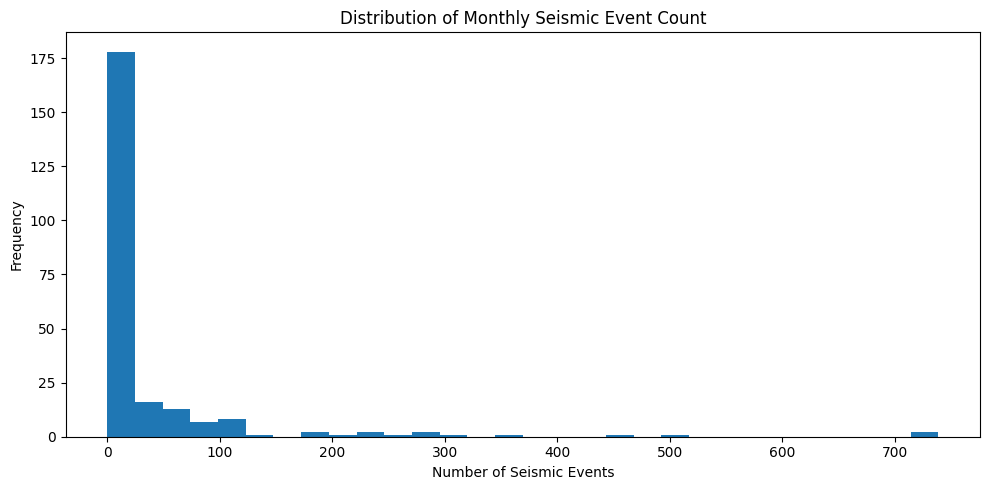

In [54]:
plt.figure(figsize=(10, 5))

plt.hist(
    model_data['Seismic_Event_Count'],
    bins=30
)

plt.title('Distribution of Monthly Seismic Event Count')
plt.xlabel('Number of Seismic Events')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

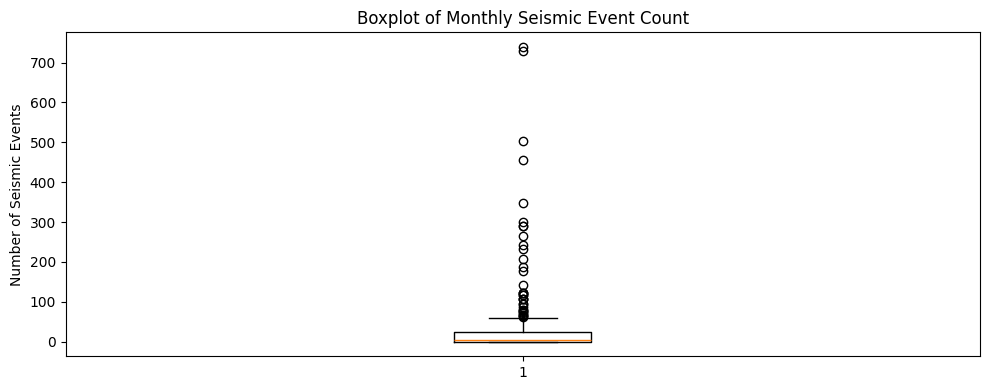

In [55]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    model_data['Seismic_Event_Count']
)

plt.title('Boxplot of Monthly Seismic Event Count')
plt.ylabel('Number of Seismic Events')

plt.tight_layout()
plt.show()

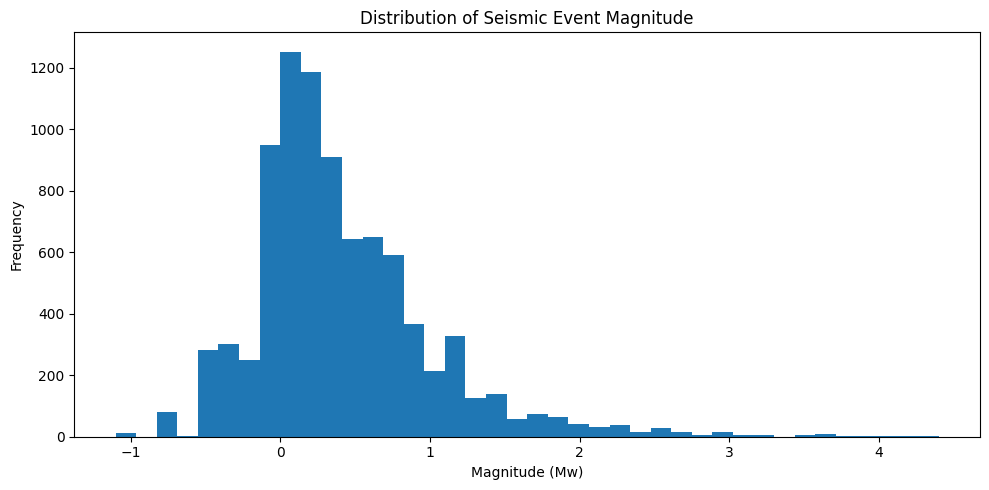

In [56]:
plt.figure(figsize=(10, 5))

plt.hist(
    event_data['Magnitude'],
    bins=40
)

plt.title('Distribution of Seismic Event Magnitude')
plt.xlabel('Magnitude (Mw)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

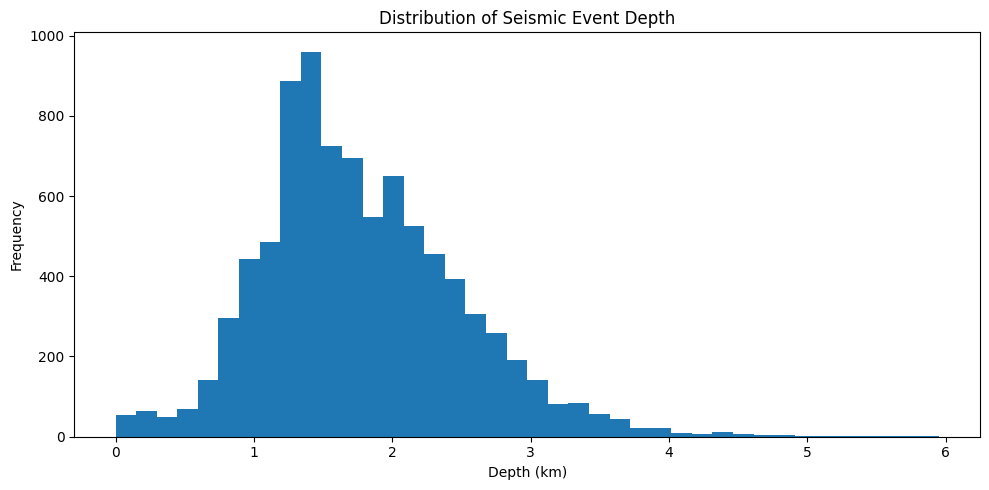

In [57]:
plt.figure(figsize=(10, 5))

plt.hist(
    event_data['Depth'],
    bins=40
)

plt.title('Distribution of Seismic Event Depth')
plt.xlabel('Depth (km)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

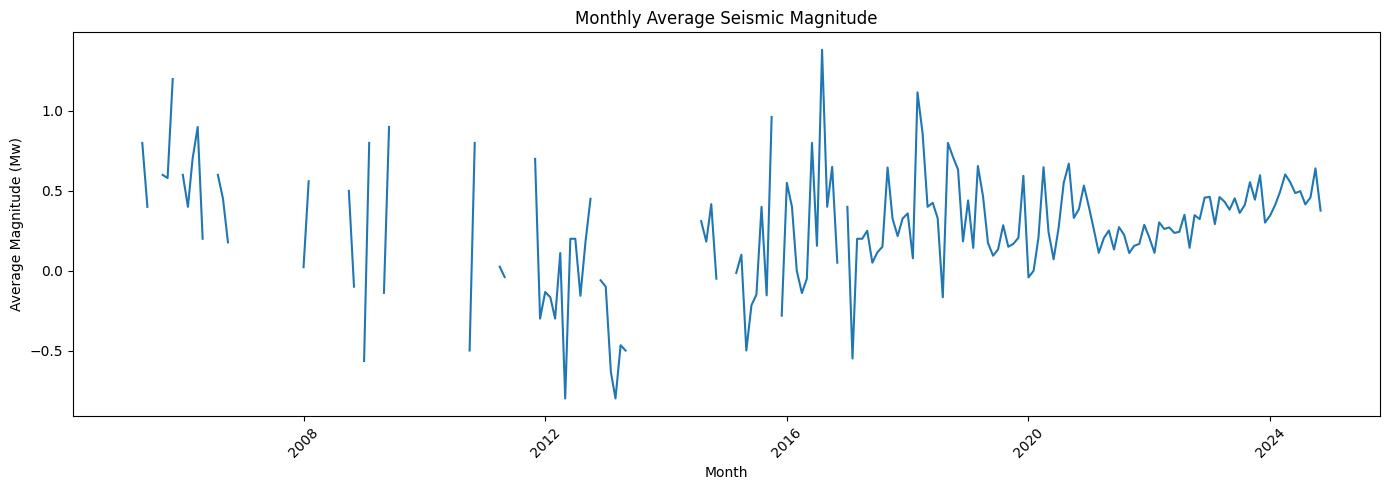

In [58]:
plt.figure(figsize=(14, 5))

plt.plot(
    model_data['Month'],
    model_data['Avg_Magnitude']
)

plt.title('Monthly Average Seismic Magnitude')
plt.xlabel('Month')
plt.ylabel('Average Magnitude (Mw)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

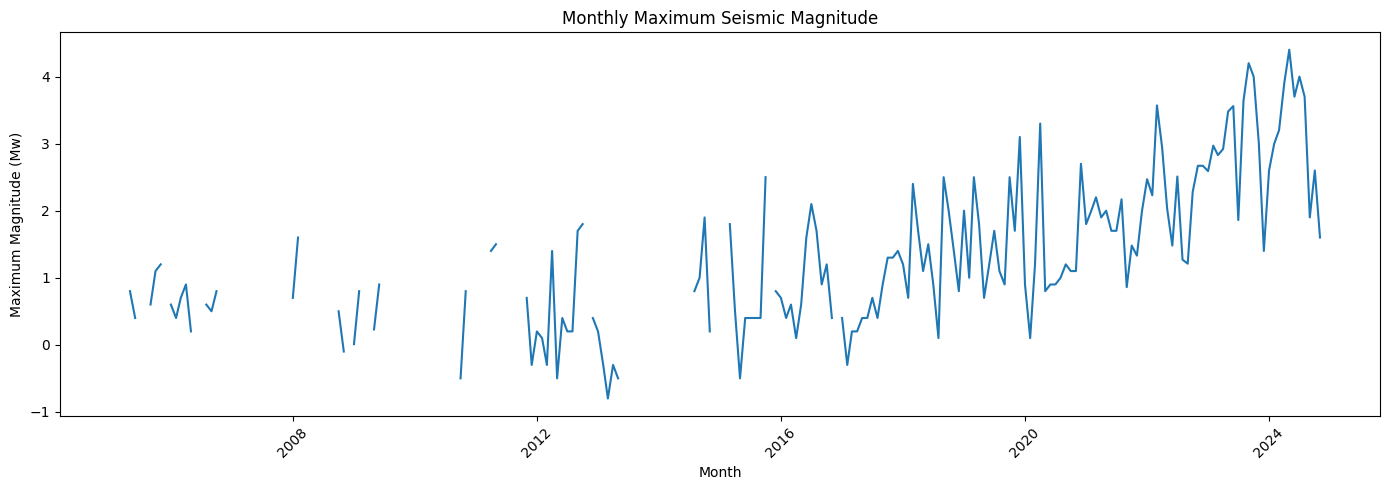

In [59]:
plt.figure(figsize=(14, 5))

plt.plot(
    model_data['Month'],
    model_data['Max_Magnitude']
)

plt.title('Monthly Maximum Seismic Magnitude')
plt.xlabel('Month')
plt.ylabel('Maximum Magnitude (Mw)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

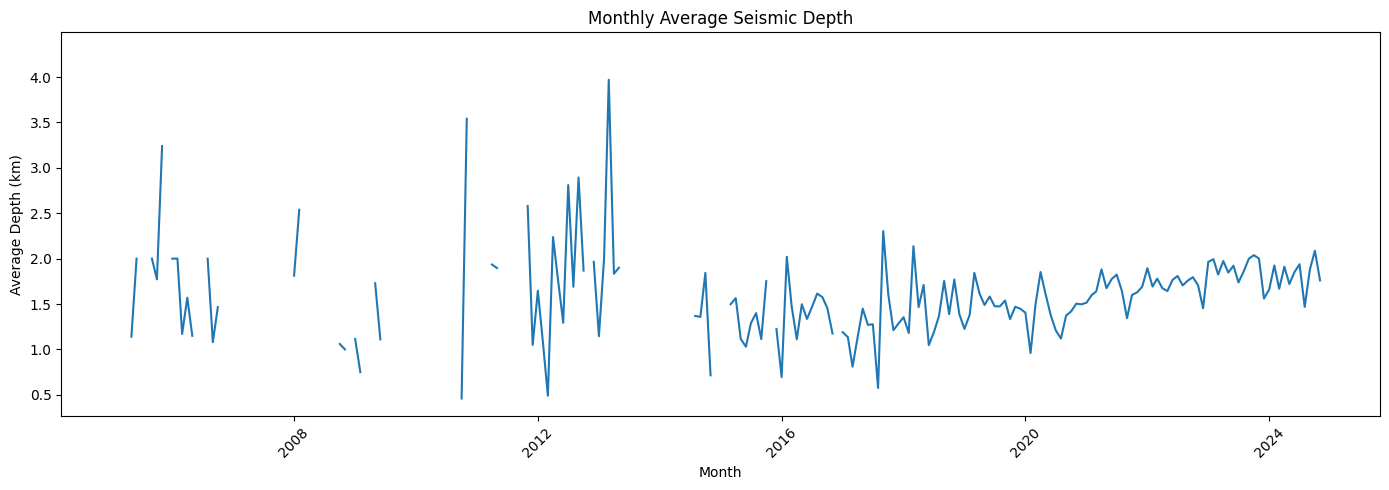

In [60]:
plt.figure(figsize=(14, 5))

plt.plot(
    model_data['Month'],
    model_data['Avg_Depth']
)

plt.title('Monthly Average Seismic Depth')
plt.xlabel('Month')
plt.ylabel('Average Depth (km)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [61]:
correlation = model_data[
    [
        'Seismic_Event_Count',
        'Avg_Magnitude',
        'Max_Magnitude',
        'Avg_Depth',
        'Max_Depth'
    ]
].corr()

display(correlation)

,Seismic_Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth
Seismic_Event_Count,1.000000,0.166959,0.712806,0.139427,0.567095
Avg_Magnitude,0.166959,1.000000,0.498235,0.237558,0.172789
Max_Magnitude,0.712806,0.498235,1.000000,0.225872,0.697916
Avg_Depth,0.139427,0.237558,0.225872,1.000000,0.542588
Max_Depth,0.567095,0.172789,0.697916,0.542588,1.000000


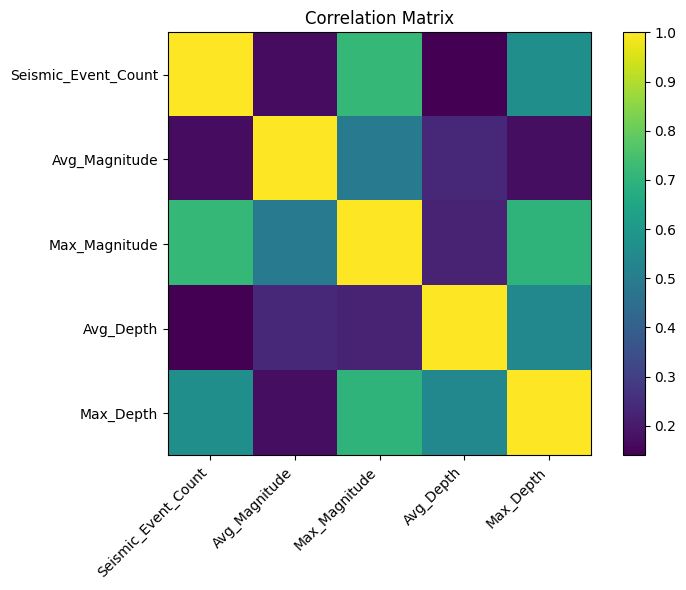

In [62]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, interpolation='none')

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

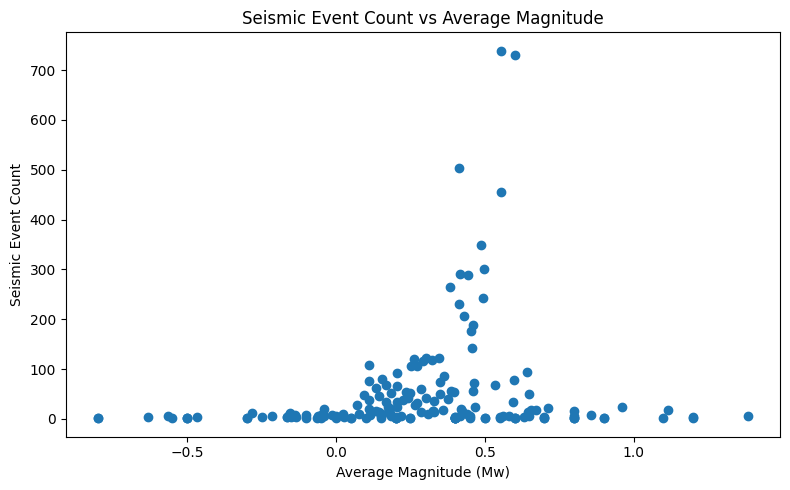

In [63]:
plt.figure(figsize=(8, 5))

plt.scatter(
    model_data['Avg_Magnitude'],
    model_data['Seismic_Event_Count']
)

plt.title('Seismic Event Count vs Average Magnitude')
plt.xlabel('Average Magnitude (Mw)')
plt.ylabel('Seismic Event Count')

plt.tight_layout()
plt.show()

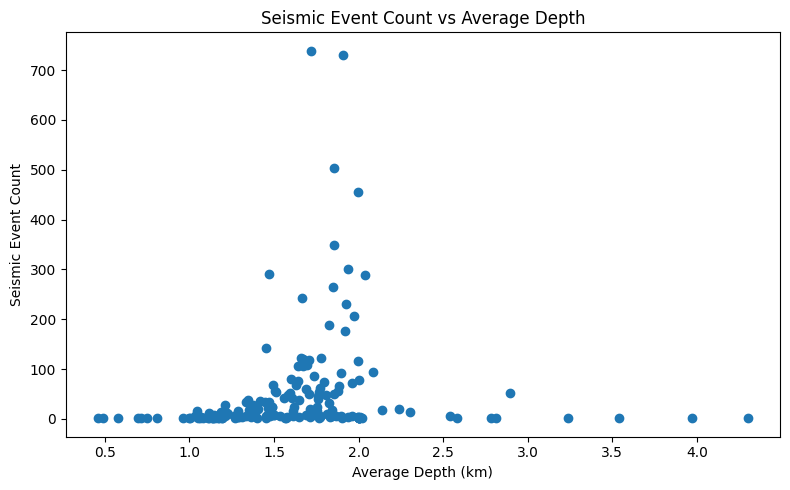

In [64]:
plt.figure(figsize=(8, 5))

plt.scatter(
    model_data['Avg_Depth'],
    model_data['Seismic_Event_Count']
)

plt.title('Seismic Event Count vs Average Depth')
plt.xlabel('Average Depth (km)')
plt.ylabel('Seismic Event Count')

plt.tight_layout()
plt.show()

In [65]:
yearly_activity = (
    model_data
    .assign(
        Year=model_data['Month'].dt.year
    )
    .groupby('Year')['Seismic_Event_Count']
    .sum()
)

display(yearly_activity)



,Seismic_Event_Count
Year,
2005,11.0
2006,33.0
2007,1.0
2008,16.0
2009,15.0
2010,26.0
2011,18.0
2012,101.0
2013,15.0


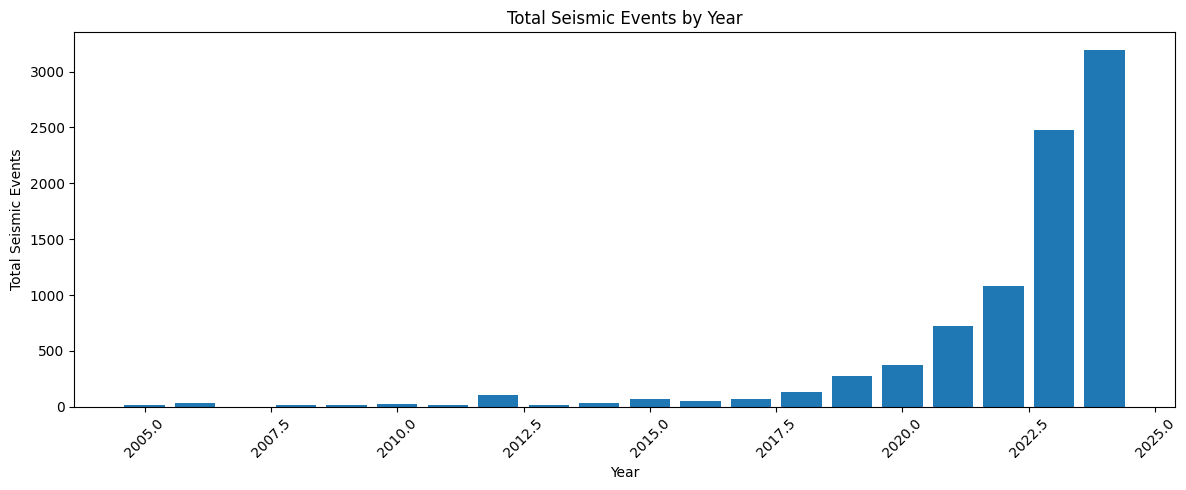

In [66]:
plt.figure(figsize=(12, 5))

plt.bar(
    yearly_activity.index,
    yearly_activity.values
)

plt.title('Total Seismic Events by Year')
plt.xlabel('Year')
plt.ylabel('Total Seismic Events')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Part 5: Define the Target and Create the Forecasting Structure**

Now we move from EDA → machine learning preparation.

This is one of the most important parts of the project, so we'll go slowly.



# **5.1 First, our prediction question**

We decided:

Predict the number of seismic events in the following month.

March 2005
    ↓
information available in March
    ↓
Predict April 2005 event count


# **5.2 Create the Target**

Your current dataset is:

model_data

Before changing it, make a copy:

In [67]:
ml_data = model_data.copy()

print("Original shape:", ml_data.shape)
display(ml_data.head())

Original shape: (237, 6)


,Month,Seismic_Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth
0,2005-03-01,2.0,-0.065,0.36,1.195,1.39
1,2005-04-01,0.0,NaN,NaN,NaN,NaN
2,2005-05-01,1.0,0.800,0.80,1.140,1.14
3,2005-06-01,1.0,0.400,0.40,2.000,2.00
4,2005-07-01,0.0,NaN,NaN,NaN,NaN


In [68]:
ml_data['Target_Next_Month'] = (
    ml_data['Seismic_Event_Count'].shift(-1)
)

In [69]:
display(
    ml_data[
        [
            'Month',
            'Seismic_Event_Count',
            'Target_Next_Month'
        ]
    ].head(15)
)

,Month,Seismic_Event_Count,Target_Next_Month
0,2005-03-01,2.0,0.0
1,2005-04-01,0.0,1.0
2,2005-05-01,1.0,1.0
3,2005-06-01,1.0,0.0
4,2005-07-01,0.0,0.0
5,2005-08-01,0.0,1.0
6,2005-09-01,1.0,5.0
7,2005-10-01,5.0,1.0
8,2005-11-01,1.0,0.0
9,2005-12-01,0.0,1.0


In [70]:
display(
    ml_data[
        [
            'Month',
            'Seismic_Event_Count',
            'Target_Next_Month'
        ]
    ].tail(5)
)

,Month,Seismic_Event_Count,Target_Next_Month
232,2024-07-01,300.0,290.0
233,2024-08-01,290.0,56.0
234,2024-09-01,56.0,95.0
235,2024-10-01,95.0,39.0
236,2024-11-01,39.0,NaN


In [71]:
ml_data = ml_data.dropna(
    subset=['Target_Next_Month']
).reset_index(drop=True)

In [72]:
print("ML dataset shape:", ml_data.shape)

ML dataset shape: (236, 7)


In [73]:
check_target = ml_data[
    [
        'Month',
        'Seismic_Event_Count',
        'Target_Next_Month'
    ]
].copy()

check_target['Expected_Target'] = (
    ml_data['Seismic_Event_Count'].shift(-1)
)

display(check_target.head(15))

,Month,Seismic_Event_Count,Target_Next_Month,Expected_Target
0,2005-03-01,2.0,0.0,0.0
1,2005-04-01,0.0,1.0,1.0
2,2005-05-01,1.0,1.0,1.0
3,2005-06-01,1.0,0.0,0.0
4,2005-07-01,0.0,0.0,0.0
5,2005-08-01,0.0,1.0,1.0
6,2005-09-01,1.0,5.0,5.0
7,2005-10-01,5.0,1.0,1.0
8,2005-11-01,1.0,0.0,0.0
9,2005-12-01,0.0,1.0,1.0


In [74]:
ml_data['Event_Count_Lag_1'] = (
    ml_data['Seismic_Event_Count'].shift(1)
)

In [75]:
ml_data['Event_Count_Lag_2'] = (
    ml_data['Seismic_Event_Count'].shift(2)
)

In [76]:
ml_data['Event_Count_Lag_3'] = (
    ml_data['Seismic_Event_Count'].shift(3)
)

# **5.10 Create Rolling Features**

Now we calculate recent activity averages.

**3-month rolling average**

In [77]:
ml_data['Event_Count_Rolling_Mean_3'] = (
    ml_data['Seismic_Event_Count']
    .rolling(window=3)
    .mean()
)

**6-month rolling average**

In [ ]:
ml_data['Event_Count_Rolling_Mean_6'] = (
    ml_data['Seismic_Event_Count']
    .rolling(window=6)
    .mean()
)

**Important Leakage Question**

You might wonder:

"Are we accidentally using future information?"

No, not with the target setup we've created.

For example, when predicting April:

March information
     ↓
April target

The March event count is already known at the end of March.

That's legitimate.

However, we need to be careful with rolling windows.

For a forecasting model, the safest formulation is to make rolling features based on information available before the prediction target.

We'll refine that in the next step.

For now, don't modify the rolling calculations yet. We're going to inspect them and make the final leakage-safe version.


**5.11 Add Magnitude/Depth Lag Features**

We can also use historical seismic characteristics.

For example:

In [78]:
ml_data['Avg_Magnitude_Lag_1'] = (
    ml_data['Avg_Magnitude'].shift(1)
)

ml_data['Max_Magnitude_Lag_1'] = (
    ml_data['Max_Magnitude'].shift(1)
)

ml_data['Avg_Depth_Lag_1'] = (
    ml_data['Avg_Depth'].shift(1)
)

ml_data['Max_Depth_Lag_1'] = (
    ml_data['Max_Depth'].shift(1)
)

These mean:

Previous month's
average magnitude
maximum magnitude
average depth
maximum depth


**5.12 Why Lag Magnitude and Depth?**

Because we're asking whether:

Recent seismic characteristics contain information useful for predicting future seismic activity.

For example:

Previous month:
High event activity
High maximum magnitude
Certain depth characteristics

             ↓

Next month:
How many events?

This gives our ML model both:

Temporal information
Lagged event counts
Rolling activity

and:

Geological/seismic information
Magnitude
Depth

That's much stronger than simply throwing the raw columns into Linear Regression and hoping geology politely explains itself.

**5.13 Inspect Our New Features**

In [79]:
display(
    ml_data.head(15)
)

,Month,Seismic_Event_Count,Avg_Magnitude,Max_Magnitude,Avg_Depth,Max_Depth,Target_Next_Month,Event_Count_Lag_1,Event_Count_Lag_2,Event_Count_Lag_3,Event_Count_Rolling_Mean_3,Avg_Magnitude_Lag_1,Max_Magnitude_Lag_1,Avg_Depth_Lag_1,Max_Depth_Lag_1
0,2005-03-01,2.0,-0.065,0.36,1.195,1.39,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-04-01,0.0,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN,-0.065,0.36,1.195,1.39
2,2005-05-01,1.0,0.800,0.80,1.140,1.14,1.0,0.0,2.0,NaN,1.000000,NaN,NaN,NaN,NaN
3,2005-06-01,1.0,0.400,0.40,2.000,2.00,0.0,1.0,0.0,2.0,0.666667,0.800,0.80,1.140,1.14
4,2005-07-01,0.0,NaN,NaN,NaN,NaN,0.0,1.0,1.0,0.0,0.666667,0.400,0.40,2.000,2.00
5,2005-08-01,0.0,NaN,NaN,NaN,NaN,1.0,0.0,1.0,1.0,0.333333,NaN,NaN,NaN,NaN
6,2005-09-01,1.0,0.600,0.60,2.000,2.00,5.0,0.0,0.0,1.0,0.333333,NaN,NaN,NaN,NaN
7,2005-10-01,5.0,0.580,1.10,1.772,2.28,1.0,1.0,0.0,0.0,2.000000,0.600,0.60,2.000,2.00
8,2005-11-01,1.0,1.200,1.20,3.240,3.24,0.0,5.0,1.0,0.0,2.333333,0.580,1.10,1.772,2.28
9,2005-12-01,0.0,NaN,NaN,NaN,NaN,1.0,1.0,5.0,1.0,2.000000,1.200,1.20,3.240,3.24


In [80]:
print("Missing values:")
print(ml_data.isnull().sum())

Missing values:
Month                          0
Seismic_Event_Count            0
Avg_Magnitude                 66
Max_Magnitude                 66
Avg_Depth                     66
Max_Depth                     66
Target_Next_Month              0
Event_Count_Lag_1              1
Event_Count_Lag_2              2
Event_Count_Lag_3              3
Event_Count_Rolling_Mean_3     2
Avg_Magnitude_Lag_1           67
Max_Magnitude_Lag_1           67
Avg_Depth_Lag_1               67
Max_Depth_Lag_1               67
dtype: int64


In [81]:
print(
    "Chronological order:",
    ml_data['Month'].is_monotonic_increasing
)

Chronological order: True


In [82]:
print("Rows:", ml_data.shape[0])
print("Columns:", ml_data.shape[1])

print("\nColumns:")
print(ml_data.columns.tolist())

Rows: 236
Columns: 15

Columns:
['Month', 'Seismic_Event_Count', 'Avg_Magnitude', 'Max_Magnitude', 'Avg_Depth', 'Max_Depth', 'Target_Next_Month', 'Event_Count_Lag_1', 'Event_Count_Lag_2', 'Event_Count_Lag_3', 'Event_Count_Rolling_Mean_3', 'Avg_Magnitude_Lag_1', 'Max_Magnitude_Lag_1', 'Avg_Depth_Lag_1', 'Max_Depth_Lag_1']


# **6.2 Decide the Split**

We have:

236 observations

We'll use approximately:

80% training

20% testing


In [83]:
train_size = int(len(ml_data) * 0.80)

print("Total observations:", len(ml_data))
print("Training observations:", train_size)
print("Testing observations:", len(ml_data) - train_size)

Total observations: 236
Training observations: 188
Testing observations: 48


In [84]:
train_data = ml_data.iloc[:train_size].copy()
test_data = ml_data.iloc[train_size:].copy()

print("Training period:")
print(train_data['Month'].min(), "to", train_data['Month'].max())

print("\nTesting period:")
print(test_data['Month'].min(), "to", test_data['Month'].max())

Training period:
2005-03-01 00:00:00 to 2020-10-01 00:00:00

Testing period:
2020-11-01 00:00:00 to 2024-10-01 00:00:00


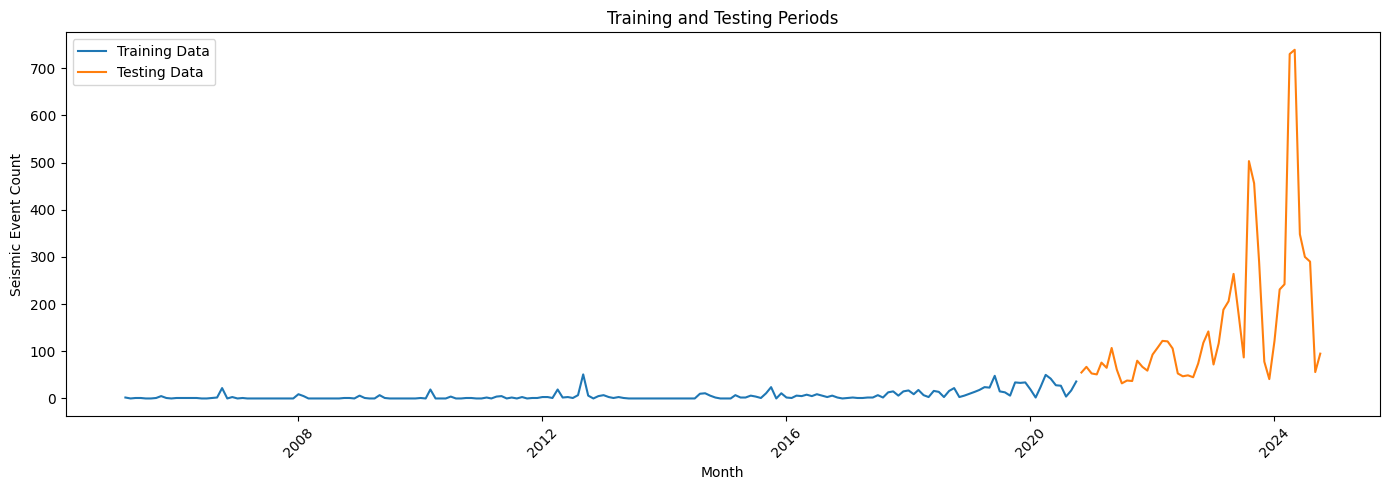

In [85]:
plt.figure(figsize=(14, 5))

plt.plot(
    train_data['Month'],
    train_data['Seismic_Event_Count'],
    label='Training Data'
)

plt.plot(
    test_data['Month'],
    test_data['Seismic_Event_Count'],
    label='Testing Data'
)

plt.title('Training and Testing Periods')
plt.xlabel('Month')
plt.ylabel('Seismic Event Count')
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [86]:
target = 'Target_Next_Month'


features = [
    'Seismic_Event_Count',
    'Avg_Magnitude',
    'Max_Magnitude',
    'Avg_Depth',
    'Max_Depth',
    'Event_Count_Lag_1',
    'Event_Count_Lag_2',
    'Event_Count_Lag_3',
    'Event_Count_Rolling_Mean_3',
    'Avg_Magnitude_Lag_1',
    'Max_Magnitude_Lag_1',
    'Avg_Depth_Lag_1',
    'Max_Depth_Lag_1'
]

In [87]:
X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (188, 13)
y_train: (188,)
X_test: (48, 13)
y_test: (48,)


In [88]:
print("Training missing values:")
print(X_train.isnull().sum())

print("\nTesting missing values:")
print(X_test.isnull().sum())

Training missing values:
Seismic_Event_Count            0
Avg_Magnitude                 66
Max_Magnitude                 66
Avg_Depth                     66
Max_Depth                     66
Event_Count_Lag_1              1
Event_Count_Lag_2              2
Event_Count_Lag_3              3
Event_Count_Rolling_Mean_3     2
Avg_Magnitude_Lag_1           67
Max_Magnitude_Lag_1           67
Avg_Depth_Lag_1               67
Max_Depth_Lag_1               67
dtype: int64

Testing missing values:
Seismic_Event_Count           0
Avg_Magnitude                 0
Max_Magnitude                 0
Avg_Depth                     0
Max_Depth                     0
Event_Count_Lag_1             0
Event_Count_Lag_2             0
Event_Count_Lag_3             0
Event_Count_Rolling_Mean_3    0
Avg_Magnitude_Lag_1           0
Max_Magnitude_Lag_1           0
Avg_Depth_Lag_1               0
Max_Depth_Lag_1               0
dtype: int64


In [89]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

## **Part 7: Build Our Baseline**

Before we train Linear Regression, Random Forest, etc., we need a baseline.

This is very important academically.

We need to answer:

"Is our machine-learning model actually better than a simple prediction?"

Otherwise a fancy model could produce impressive-looking numbers while accomplishing approximately nothing. A surprisingly common human tradition.

**7.1 What Is Our Baseline?**

We'll use a very simple forecasting rule:

Predict next month's event count as equal to the current month's event count.

So:

Current month = 50 events
        ↓
Prediction for next month = 50

This is called a naive/persistence forecast.

**7.2 Create the Baseline Prediction**

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Naive baseline:
# predict next month's event count using current month's event count

baseline_predictions = test_data['Seismic_Event_Count'].values
baseline_actual = test_data['Target_Next_Month'].values

print("Baseline predictions:")
print(baseline_predictions[:10])

print("\nActual target values:")
print(baseline_actual[:10])

Baseline predictions:
[ 55.  67.  53.  51.  76.  65. 107.  61.  32.  38.]

Actual target values:
[ 67.  53.  51.  76.  65. 107.  61.  32.  38.  37.]


In [92]:
baseline_mae = mean_absolute_error(
    baseline_actual,
    baseline_predictions
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 68.45833333333333


In [93]:
baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_actual,
        baseline_predictions
    )
)

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 126.47463513817043


In [94]:
baseline_r2 = r2_score(
    baseline_actual,
    baseline_predictions
)

print("Baseline R²:", baseline_r2)

Baseline R²: 0.3861487724441186


In [95]:
baseline_results = pd.DataFrame({
    'Model': ['Naive Baseline'],
    'MAE': [baseline_mae],
    'RMSE': [baseline_rmse],
    'R2': [baseline_r2]
})

display(baseline_results)

,Model,MAE,RMSE,R2
0,Naive Baseline,68.458333,126.474635,0.386149


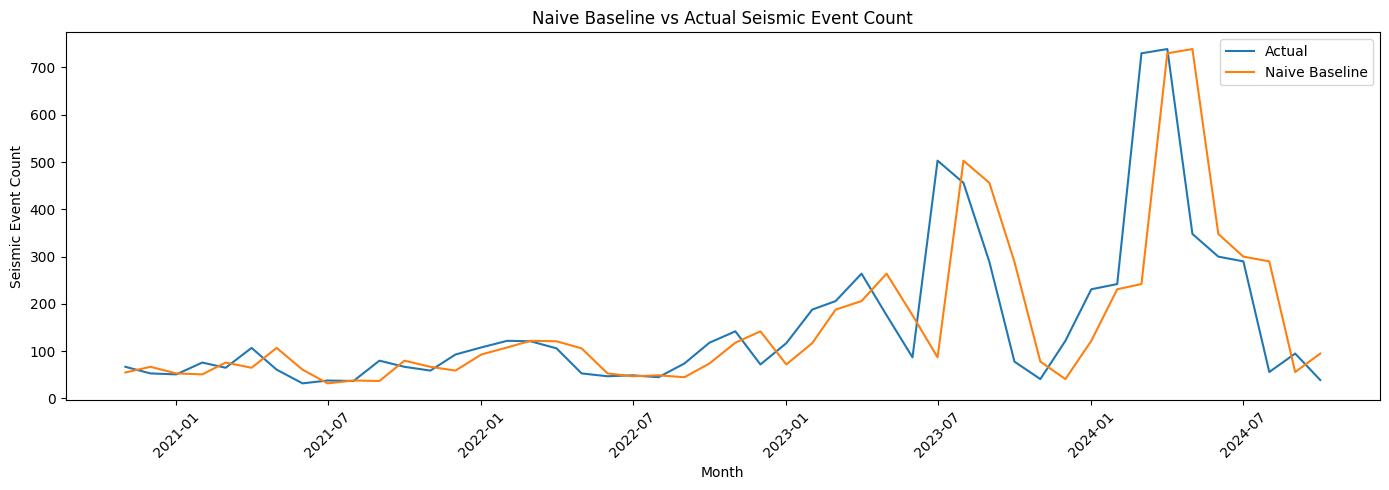

In [96]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_data['Month'],
    baseline_actual,
    label='Actual'
)

plt.plot(
    test_data['Month'],
    baseline_predictions,
    label='Naive Baseline'
)

plt.title('Naive Baseline vs Actual Seismic Event Count')
plt.xlabel('Month')
plt.ylabel('Seismic Event Count')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [97]:
training_mean = y_train.mean()

mean_predictions = np.full(
    len(y_test),
    training_mean
)

mean_mae = mean_absolute_error(
    y_test,
    mean_predictions
)

mean_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        mean_predictions
    )
)

mean_r2 = r2_score(
    y_test,
    mean_predictions
)

print("Historical Mean Baseline")
print("Prediction value:", training_mean)
print("MAE:", mean_mae)
print("RMSE:", mean_rmse)
print("R2:", mean_r2)

Historical Mean Baseline
Prediction value: 6.175531914893617
MAE: 150.90780141843973
RMSE: 220.97810808125192
R2: -0.87393602509568


In [98]:
baseline_comparison = pd.DataFrame({
    'Model': [
        'Historical Mean',
        'Naive Previous Month'
    ],
    'MAE': [
        mean_mae,
        baseline_mae
    ],
    'RMSE': [
        mean_rmse,
        baseline_rmse
    ],
    'R2': [
        mean_r2,
        baseline_r2
    ]
})

display(baseline_comparison)

,Model,MAE,RMSE,R2
0,Historical Mean,150.907801,220.978108,-0.873936
1,Naive Previous Month,68.458333,126.474635,0.386149


# **Part 8: Preprocessing + First ML Model**

Now we're finally going to train our first real machine-learning model.

We'll start with:

**Linear Regression**

Why start there?

Because it's simple, interpretable, and gives us a strong reference point before we move to more complicated models.

Our workflow will be:

X_train
   ↓
Imputation
   ↓
Scaling
   ↓
Linear Regression
   ↓
Predictions
   ↓
MAE / RMSE / R²
   ↓
Compare with baseline

**8.1 Import the required tools**

In [99]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


linear_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

In [100]:
linear_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('model', LinearRegression())])

In [101]:
linear_predictions = linear_pipeline.predict(
    X_test
)

print("First 10 predictions:")
print(linear_predictions[:10])

print("\nFirst 10 actual values:")
print(y_test.values[:10])

First 10 predictions:
[34.78231795 41.31639576 41.70992668 49.41852227 63.6731141  51.57664785
 73.2142581  58.96856763 41.47223765 53.64921565]

First 10 actual values:
[ 67.  53.  51.  76.  65. 107.  61.  32.  38.  37.]


In [102]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression
MAE: 77.26707340669465
RMSE: 133.9217498268394
R²: 0.31173055703593355


In [103]:
linear_results = pd.DataFrame({
    'Model': [
        'Naive Previous Month',
        'Linear Regression'
    ],
    'MAE': [
        baseline_mae,
        linear_mae
    ],
    'RMSE': [
        baseline_rmse,
        linear_rmse
    ],
    'R2': [
        baseline_r2,
        linear_r2
    ]
})

display(linear_results)

,Model,MAE,RMSE,R2
0,Naive Previous Month,68.458333,126.474635,0.386149
1,Linear Regression,77.267073,133.921750,0.311731


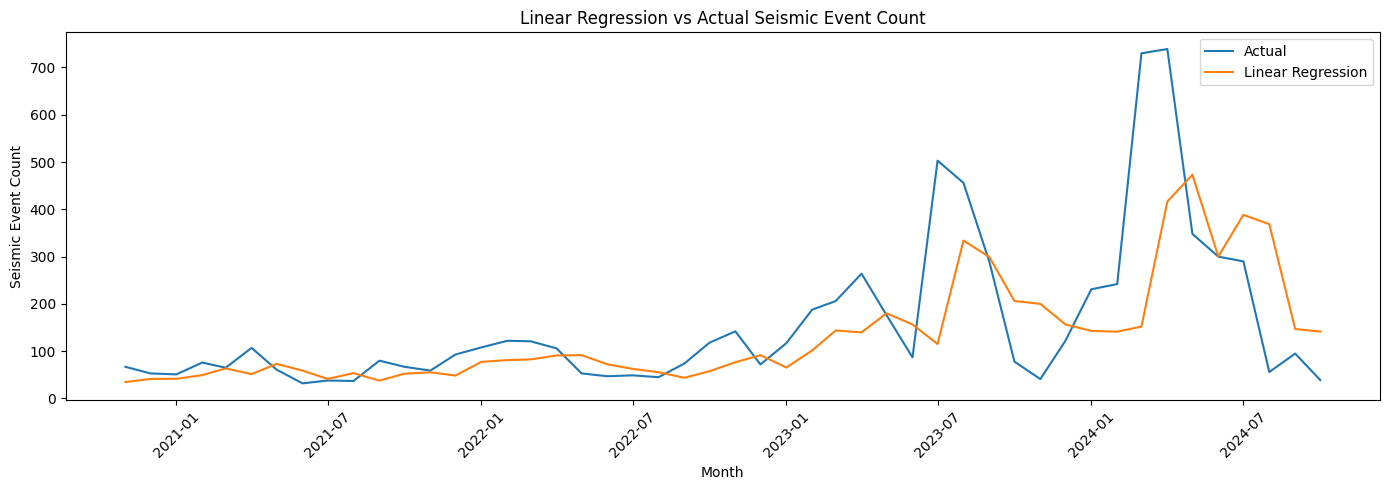

In [104]:
plt.figure(figsize=(14, 5))

plt.plot(
    test_data['Month'],
    y_test,
    label='Actual'
)

plt.plot(
    test_data['Month'],
    linear_predictions,
    label='Linear Regression'
)

plt.title('Linear Regression vs Actual Seismic Event Count')
plt.xlabel('Month')
plt.ylabel('Seismic Event Count')

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()